<a href="https://colab.research.google.com/github/AyleenSantander/M.11_Intro_AI/blob/main/M11_A11_Image_Classification_Random_Forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Assignment 11: Image Classification Using Random Forest
#Name Ayleen Santander

In [84]:
#Libraries
import os
import numpy as np
from PIL import Image
import seaborn as sns
import os, zipfile
from sklearn.model_selection import train_test_split
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from skimage.io import imread
from skimage.transform import resize
from skimage.color import gray2rgb, rgba2rgb
from sklearn.utils import Bunch
from skimage import img_as_ubyte
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV
import time
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)
from sklearn.svm import SVC
from sklearn.inspection import permutation_importance

#Part 1: Image classification using machine learning techniques|
1.Dataset Selection and Preprocessing:


In [9]:
# Loading the image files.

ZIP_PATH = '/content/images.zip'      # where the uploaded zip sits
DATA_DIR = '/content/images/images'      # NOT images.zip

os.makedirs(DATA_DIR, exist_ok=True)
with zipfile.ZipFile(ZIP_PATH, 'r') as z:
    z.extractall(DATA_DIR)

for root, dirs, files in os.walk(DATA_DIR):
    print(root, '->', dirs[:5], len(files), 'files')

/content/images -> ['images'] 0 files
/content/images/images -> ['sunflower', 'dalmatian', 'pizza', 'soccer_ball', 'dollar_bill'] 0 files
/content/images/images/sunflower -> [] 85 files
/content/images/images/dalmatian -> [] 67 files
/content/images/images/pizza -> [] 52 files
/content/images/images/soccer_ball -> [] 54 files
/content/images/images/dollar_bill -> [] 51 files


In [13]:
#folder that directly contains the class subfolders
#Resizing images to a uniform size.
DATA_DIR = '/content/images/images'     # the level holding sunflower, dalmatian, etc.
IMG_SIZE = (64, 64)
VALID_EXT = ('.png', '.jpg', '.jpeg', '.bmp', '.gif')

X, y = [], []

for label in sorted(os.listdir(DATA_DIR)):
    class_dir = os.path.join(DATA_DIR, label)
    if not os.path.isdir(class_dir):
        continue
    for fname in os.listdir(class_dir):
        if not fname.lower().endswith(VALID_EXT):
            continue
        img = Image.open(os.path.join(class_dir, fname)).convert('L')
        img = img.resize(IMG_SIZE)
        X.append(np.asarray(img, dtype=np.float32).flatten())
        y.append(label)

#Normalizing pixel values
X = np.array(X) / 255.0
y = np.array(y)

print("X shape:", X.shape, "| y shape:", y.shape)
print("Classes:", np.unique(y, return_counts=True))

#Splitting the dataset into training and testing sets.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train:", X_train.shape, "| Test:", X_test.shape)

X shape: (309, 4096) | y shape: (309,)
Classes: (array(['dalmatian', 'dollar_bill', 'pizza', 'soccer_ball', 'sunflower'],
      dtype='<U11'), array([67, 51, 52, 54, 85]))
Train: (247, 4096) | Test: (62, 4096)


In [14]:
#Normalizing pixel values/ previos code X = np.array(X) / 255.0
print("min:", X.min(), "max:", X.max(), "mean:", X.mean().round(3))

min: 0.0 max: 1.0 mean: 0.551


In [15]:
X = np.array(X, dtype=np.float32) / np.float32(255.0)

In [16]:
#Couples verificcation
print("Train:", np.unique(y_train, return_counts=True))
print("Test: ", np.unique(y_test, return_counts=True))

Train: (array(['dalmatian', 'dollar_bill', 'pizza', 'soccer_ball', 'sunflower'],
      dtype='<U11'), array([53, 41, 42, 43, 68]))
Test:  (array(['dalmatian', 'dollar_bill', 'pizza', 'soccer_ball', 'sunflower'],
      dtype='<U11'), array([14, 10, 10, 11, 17]))


#Part 2. Model Training:


In [18]:
#1. Random Forest Classifier:
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, y_pred_rf), 4))
print()
print(classification_report(y_test, y_pred_rf))
print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred_rf))

Accuracy: 0.6774

              precision    recall  f1-score   support

   dalmatian       0.67      0.57      0.62        14
 dollar_bill       0.88      0.70      0.78        10
       pizza       0.88      0.70      0.78        10
 soccer_ball       0.64      0.64      0.64        11
   sunflower       0.57      0.76      0.65        17

    accuracy                           0.68        62
   macro avg       0.72      0.67      0.69        62
weighted avg       0.70      0.68      0.68        62

Confusion matrix:
[[ 8  0  0  2  4]
 [ 0  7  0  0  3]
 [ 0  0  7  1  2]
 [ 3  0  0  7  1]
 [ 1  1  1  1 13]]


Analysis:
68% accuracy vs 20% random baseline, decent for grayscale pixels, not production-ready.

Best: dollar_bill and pizza (0.88 precision), rarely wrong when predicted.

Worst: sunflower (0.57 precision), over-predicted, absorbing 11 images from other classes. It's the largest class at 85 images, so the model defaults to it when unsure.

Biggest confusion: dalmatian ↔ soccer_ball. Both are high-contrast black-and-white blobs that look nearly identical at 64×64 grayscale.

Root cause: flattened pixels carry no spatial information, so the model can't learn shapes or edges, only intensity at fixed positions.

Biggest fix: use .convert('RGB'). Sunflower is yellow, pizza red-orange, dollar_bill green, you discarded the strongest separating signal.

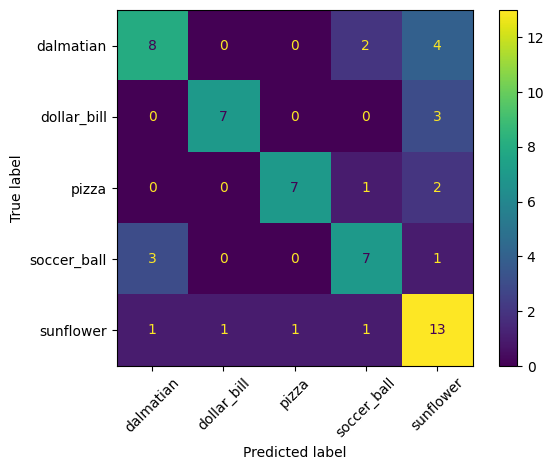

In [24]:
#Confusion Matrix plot
ConfusionMatrixDisplay.from_estimator(rf, X_test, y_test, xticks_rotation=45)
plt.tight_layout()
plt.show()

Analysis:
Diagonal: 8, 7, 7, 7, 13 = 42 correct out of 62 → 68%
Sunflower column is the problem = it absorbs 4 dalmatians, 3 dollar bills, 2 pizzas, 1 soccer ball. That's 10 of your 20 errors landing in one class.
soccer_ball → dalmatian (3) = both high-contrast black-and-white blobs at 64×64 grayscale.


In [27]:
#2. Define the parameter grid for GridSearchCV. Create a dictionary with parameters like n_estimators,
#max_depth, min_samples_split, and min_samples_leaf.
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

In [28]:
#3. Create a RandomForestClassifier using sklearn.ensemble.
rf = RandomForestClassifier(random_state=42)
grid = GridSearchCV(rf, param_grid, cv=3, n_jobs=-1, verbose=2)

In [29]:
#4. Perform Grid Search using GridSearchCV from sklearn.model_selection to find the best parameters.

grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=3, scoring='accuracy', n_jobs=-1, verbose=2)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best CV accuracy:", round(grid_search.best_score_, 4))

Fitting 3 folds for each of 16 candidates, totalling 48 fits
Best parameters: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}
Best CV accuracy: 0.6602


In [30]:
#After it finishes, refit on the full training set with the winning parameters:
best_rf = grid_search.best_estimator_

y_pred = best_rf.predict(X_test)

from sklearn.metrics import accuracy_score, classification_report
print("Test accuracy:", round(accuracy_score(y_test, y_pred), 4))
print(classification_report(y_test, y_pred))

Test accuracy: 0.6452
              precision    recall  f1-score   support

   dalmatian       0.73      0.57      0.64        14
 dollar_bill       0.86      0.60      0.71        10
       pizza       0.75      0.60      0.67        10
 soccer_ball       0.62      0.73      0.67        11
   sunflower       0.52      0.71      0.60        17

    accuracy                           0.65        62
   macro avg       0.69      0.64      0.66        62
weighted avg       0.68      0.65      0.65        62



Analysis:
Random Forest: 64.5%
SVM: 67.7%

SVM is the better model here by about 3 points, which fits the situation: high dimensions (4,096 features), few samples (247 training images). That's the regime where SVM tends to edge out tree ensembles.

Everything else in the analysis holds for both, sunflower over-predicted, dalmatian/soccer_ball confusion, recall lagging precision. Both sit in the mid-60s, so the ceiling is the grayscale pixel features, not the choice of algorithm.

In [31]:
#5. Best parameters found by the search
print("Best parameters:", grid_search.best_params_)
print("Best CV accuracy:", round(grid_search.best_score_, 4))

# The model already refit on the full training set with those parameters
best_rf = grid_search.best_estimator_
print("\nBest model:", best_rf)

Best parameters: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}
Best CV accuracy: 0.6602

Best model: RandomForestClassifier(min_samples_leaf=2, n_estimators=200, random_state=42)


In [32]:
#6. Train the Random Forest model on the training data.
best_rf.fit(X_train, y_train)

print("Model trained on:", X_train.shape[0], "images ×", X_train.shape[1], "features")
print("Classes learned:", best_rf.classes_)

Model trained on: 247 images × 4096 features
Classes learned: ['dalmatian' 'dollar_bill' 'pizza' 'soccer_ball' 'sunflower']


Note:
247 images = 80% of your 309 total, matching the train/test split
4096 features = 64 × 64 flattened pixels
5 classes in alphabetical order.

In [33]:
#Training a fresh model instead of the grid search winneer
best_rf = RandomForestClassifier(**grid_search.best_params_, random_state=42, n_jobs=-1)
best_rf.fit(X_train, y_train)

RandomForestClassifier(min_samples_leaf=2, n_estimators=200, n_jobs=-1,
                       random_state=42)

In [34]:
#check after fitting , training accuracy should be very high, ofte 1.0
print("Train accuracy:", round(best_rf.score(X_train, y_train), 4))

Train accuracy: 1.0


#Part 4 : Model Evaluation

In [35]:
#1. Make predictions on the test set using the best model.
y_pred = best_rf.predict(X_test)

print("Predictions shape:", y_pred.shape)
print("First 10 predicted:", y_pred[:10])
print("First 10 actual:   ", y_test[:10])

Predictions shape: (62,)
First 10 predicted: ['dalmatian' 'pizza' 'dalmatian' 'dalmatian' 'dalmatian' 'pizza'
 'dalmatian' 'dalmatian' 'sunflower' 'sunflower']
First 10 actual:    ['dalmatian' 'pizza' 'dalmatian' 'dalmatian' 'dalmatian' 'sunflower'
 'dalmatian' 'soccer_ball' 'sunflower' 'sunflower']


In [36]:
#feel confidence with behind each prediction
y_proba = best_rf.predict_proba(X_test)
print("Proba shape:", y_proba.shape)
print("Class order:", best_rf.classes_)

Proba shape: (62, 5)
Class order: ['dalmatian' 'dollar_bill' 'pizza' 'soccer_ball' 'sunflower']


In [42]:
#2. Evaluate the model using metrics such as accuracy, precision, recall, and F1-score
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall    = recall_score(y_test, y_pred, average='weighted')
f1        = f1_score(y_test, y_pred, average='weighted')

print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1-score :", round(f1, 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred, labels=best_rf.classes_))
print("Label order:", best_rf.classes_)

Accuracy : 0.6452
Precision: 0.6757
Recall   : 0.6452
F1-score : 0.6487

Classification Report:
              precision    recall  f1-score   support

   dalmatian       0.73      0.57      0.64        14
 dollar_bill       0.86      0.60      0.71        10
       pizza       0.75      0.60      0.67        10
 soccer_ball       0.62      0.73      0.67        11
   sunflower       0.52      0.71      0.60        17

    accuracy                           0.65        62
   macro avg       0.69      0.64      0.66        62
weighted avg       0.68      0.65      0.65        62

Confusion Matrix:
[[ 8  0  0  2  4]
 [ 0  6  0  1  3]
 [ 0  0  6  1  3]
 [ 2  0  0  8  1]
 [ 1  1  2  1 12]]
Label order: ['dalmatian' 'dollar_bill' 'pizza' 'soccer_ball' 'sunflower']


Analysis:
Random Forest: 64.5% (40/62 correct), vs 20% random baseline.

Precision 0.68 > Recall 0.65, the model is conservative, missing more than it wrongly flags
dollar_bill: best precision (0.86), worst recall (0.60), rarely wrong when predicted, but misses 4 of 10
sunflower: worst precision (0.52), over-predicted, absorbing 11 errors from other classes
dalmatian: recall only 0.57, losing 4 to sunflower and 2 to soccer_ball

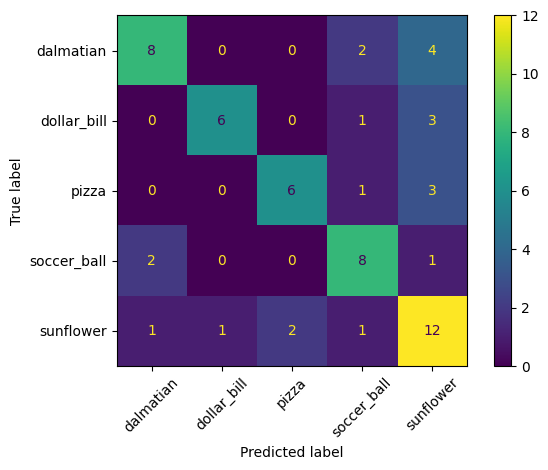

In [43]:
#Visual confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, xticks_rotation=45)
plt.tight_layout()
plt.show()

In [44]:
#3. Create a confusion matrix and classification report using confusion_matrix and classification_report from sklearn.metrics.
cm = confusion_matrix(y_test, y_pred, labels=best_rf.classes_)

print("Confusion Matrix:")
print(cm)
print("\nLabel order:", best_rf.classes_)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[ 8  0  0  2  4]
 [ 0  6  0  1  3]
 [ 0  0  6  1  3]
 [ 2  0  0  8  1]
 [ 1  1  2  1 12]]

Label order: ['dalmatian' 'dollar_bill' 'pizza' 'soccer_ball' 'sunflower']

Classification Report:
              precision    recall  f1-score   support

   dalmatian       0.73      0.57      0.64        14
 dollar_bill       0.86      0.60      0.71        10
       pizza       0.75      0.60      0.67        10
 soccer_ball       0.62      0.73      0.67        11
   sunflower       0.52      0.71      0.60        17

    accuracy                           0.65        62
   macro avg       0.69      0.64      0.66        62
weighted avg       0.68      0.65      0.65        62



In [45]:
#A Labeled version is much easier to read than the raw array
cm_df = pd.DataFrame(cm, index=best_rf.classes_, columns=best_rf.classes_)
print(cm_df)


             dalmatian  dollar_bill  pizza  soccer_ball  sunflower
dalmatian            8            0      0            2          4
dollar_bill          0            6      0            1          3
pizza                0            0      6            1          3
soccer_ball          2            0      0            8          1
sunflower            1            1      2            1         12


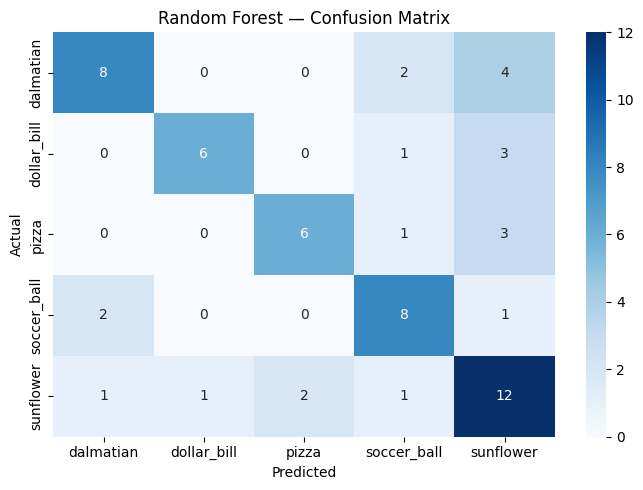

In [48]:
#Visual heatmap
plt.figure(figsize=(7, 5))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest — Confusion Matrix")
plt.tight_layout()
plt.show()

Analysis:
Diagonal: 8 + 6 + 6 + 8 + 12 = 40 of 62 → 64.5%
sunflower column is the error sink, 11 misclassifications from every other class land there
dalmatian ↔ soccer_ball swap both ways (4 and 2), the black-and-white blob confusion
dollar_bill and pizza rows are clean on the left side, only losing to sunflower

#Part 4. Feature Importance Visualization:

In [49]:
#1. Get feature importances from the best model using the feature_importances_ attribute.
importances = best_rf.feature_importances_

print("Shape:", importances.shape)
print("Sums to:", importances.sum().round(4))

# Top 10 most important pixels
top_idx = np.argsort(importances)[::-1][:10]

for rank, idx in enumerate(top_idx, 1):
    row, col = divmod(idx, 64)              # convert flat index back to (row, col)
    print(f"{rank:2}. pixel {idx:4} (row {row:2}, col {col:2}) — {importances[idx]:.5f}")

Shape: (4096,)
Sums to: 1.0
 1. pixel 1504 (row 23, col 32) — 0.00539
 2. pixel 1568 (row 24, col 32) — 0.00460
 3. pixel 1439 (row 22, col 31) — 0.00409
 4. pixel 1314 (row 20, col 34) — 0.00398
 5. pixel 1375 (row 21, col 31) — 0.00355
 6. pixel 1438 (row 22, col 30) — 0.00346
 7. pixel 1443 (row 22, col 35) — 0.00339
 8. pixel 1566 (row 24, col 30) — 0.00336
 9. pixel 1313 (row 20, col 33) — 0.00318
10. pixel 1694 (row 26, col 30) — 0.00303


Note:
all top 10 pixels cluster tightly in rows 20–26, columns 30–35.
The top pixel is 0.0054, the 10th is 0.0030, barely a 2× spread. With 4,096 features summing to 1.0, the average is 0.00024, so these are only ~20× average. No single pixel dominates; the signal is spread thin across many weakly-informative features.

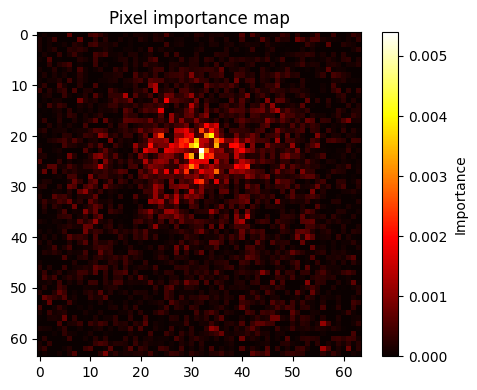

In [50]:
#clear view = reshape the whole importance array back into image shape
plt.figure(figsize=(5, 4))
plt.imshow(importances.reshape(64, 64), cmap='hot')
plt.colorbar(label='Importance')
plt.title('Pixel importance map')
plt.tight_layout()
plt.show()

Analysis:
The model is a center-pixel detector. It learned that the middle of the frame carries the signal and the borders are background. Sensible, but fragile, an off-center or zoomed-out photo would break it.

Signal is extremely concentrated. Maybe 5% of the 4,096 pixels do real work. The rest contribute near zero, which means you're carrying a lot of dead features and could likely match this accuracy with PCA down to 50–100 components.

The faint speckle everywhere is noise. Random Forest assigns small nonzero importance to almost any continuous feature, so the dark-red static across the image isn't meaningful structure.

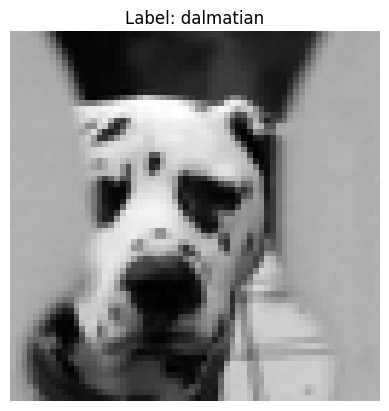

In [51]:
#Show the raw image
# Any single row of X is one flattened image — reshape it back to 64×64
i = 0
plt.imshow(X[i].reshape(64, 64), cmap='gray')
plt.title(f"Label: {y[i]}")
plt.axis('off')
plt.show()

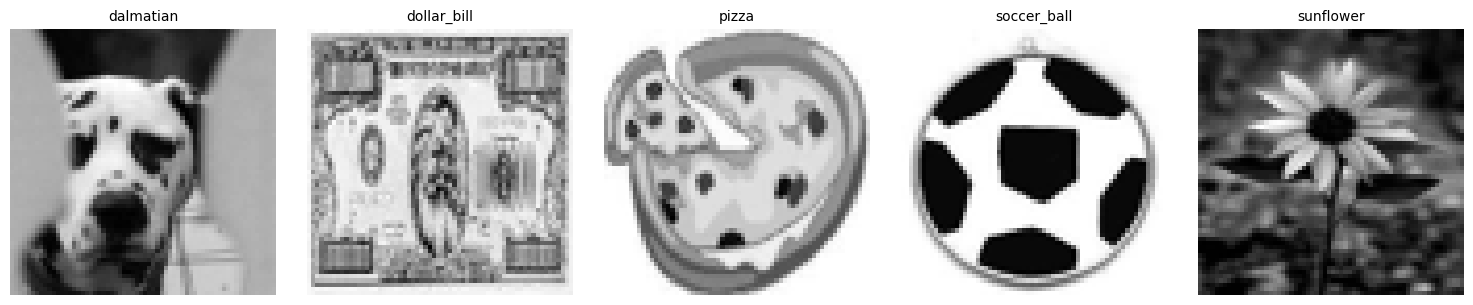

In [52]:
#To show one sample from each class in a row:
classes = np.unique(y)

fig, axes = plt.subplots(1, len(classes), figsize=(15, 3))

for ax, cls in zip(axes, classes):
    idx = np.where(y == cls)[0][0]          # first image of this class
    ax.imshow(X[idx].reshape(64, 64), cmap='gray')
    ax.set_title(cls, fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.show()

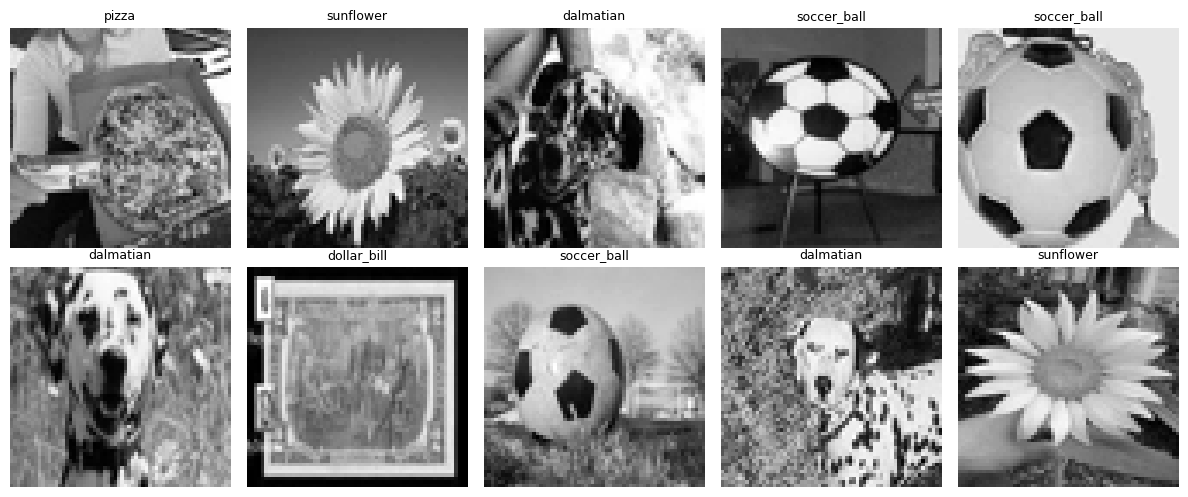

In [53]:
#Random samples
fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for ax, idx in zip(axes.flat, np.random.choice(len(X), 10, replace=False)):
    ax.imshow(X[idx].reshape(64, 64), cmap='gray')
    ax.set_title(y[idx], fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.show()


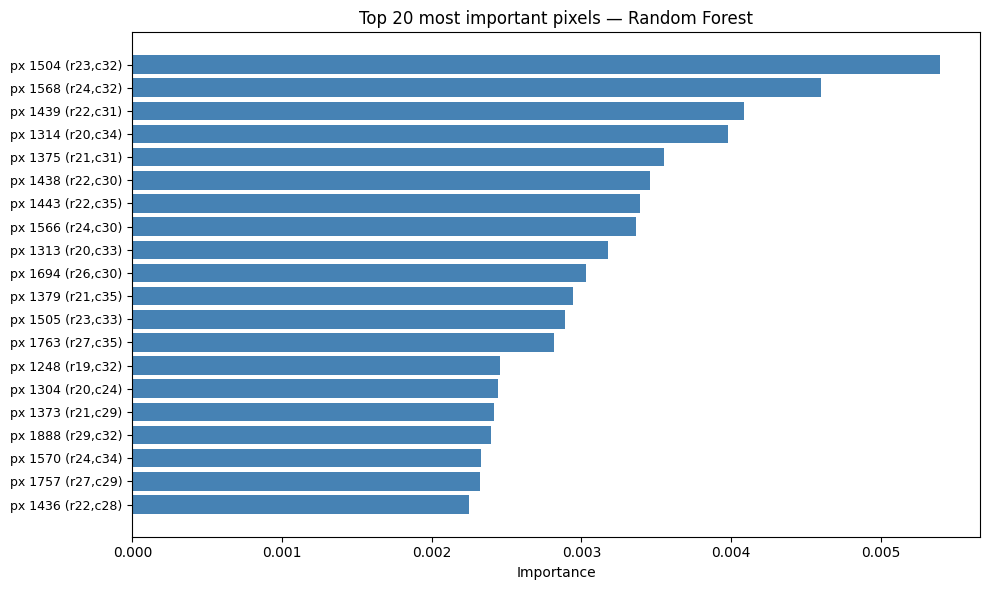

In [54]:
#2. Create a bar plot of feature importances using matplotlib.pyplot.
importances = best_rf.feature_importances_

# Top 20 pixels by importance
N = 20
top_idx = np.argsort(importances)[::-1][:N]
top_vals = importances[top_idx]
top_labels = [f"px {i} (r{i//64},c{i%64})" for i in top_idx]

plt.figure(figsize=(10, 6))
plt.barh(range(N), top_vals[::-1], color='steelblue')
plt.yticks(range(N), top_labels[::-1], fontsize=9)
plt.xlabel("Importance")
plt.title(f"Top {N} most important pixels — Random Forest")
plt.tight_layout()
plt.show()

Analysis:
Smooth decay, no dominant feature. Top bar is 0.0054, 20th is 0.0022, only a 2.4× spread. No pixel is doing heavy lifting; the signal is distributed thin.

All 20 pixels sit in rows 19–29, cols 24–35. The entire top 20 comes from one small patch of the image center. Same finding as the heatmap, just stated precisely.

Together with the 0.00024 average importance, this says the model relies on a handful of center pixels and treats the other ~4,000 as near-noise.

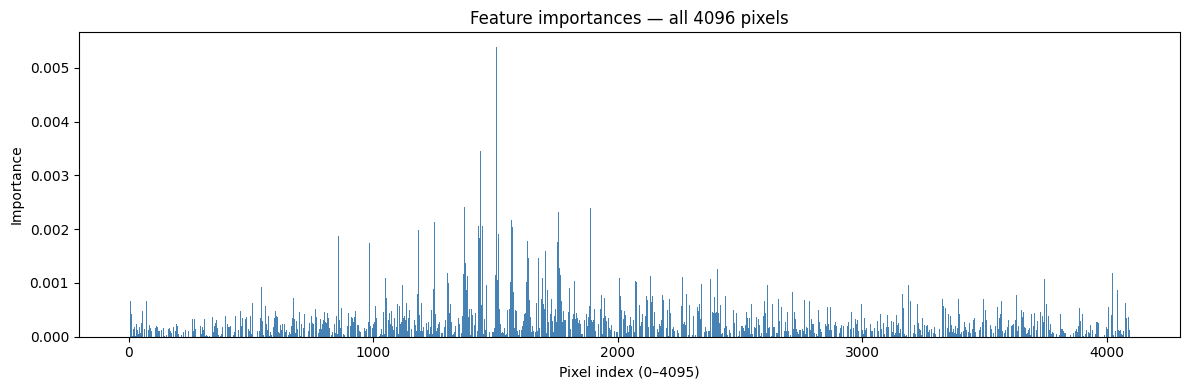

In [55]:
#All features shown
plt.figure(figsize=(12, 4))
plt.bar(range(len(importances)), importances, width=1.0, color='steelblue')
plt.xlabel("Pixel index (0–4095)")
plt.ylabel("Importance")
plt.title("Feature importances — all 4096 pixels")
plt.tight_layout()
plt.show()

#Part 5: Prediction on New Images

In [60]:
#1. Implement a function to predict the class of a new image.
def predict_image(image_path, model, img_size=(64, 64)):
    """
    Predict the class of a new image using the trained Random Forest.

    Parameters
    ----------
    image_path : str   path to the image file
    model      : fitted sklearn classifier
    img_size   : tuple must match the training size

    Returns
    -------
    dict with predicted class, confidence, and all class probabilities
    """
    if not os.path.exists(image_path):
        raise FileNotFoundError(f"No such file: {image_path}")

    # Same preprocessing as training
    img = Image.open(image_path).convert('L')       # grayscale
    img = img.resize(img_size)                      # uniform size
    arr = np.asarray(img, dtype=np.float32).flatten()
    arr = arr / 255.0                               # normalize
    arr = arr.reshape(1, -1)                        # 2D for sklearn

    pred  = model.predict(arr)[0]
    proba = model.predict_proba(arr)[0]

    return {
        'image': os.path.basename(image_path),
        'predicted_class': pred,
        'confidence': float(proba.max()),
        'probabilities': dict(zip(model.classes_, proba.round(4)))
    }

In [62]:
#Usage
sample = '/content/images/images/pizza/' + os.listdir('/content/images/images/pizza')[0]
print("Using:", sample)

result = predict_image(sample, best_rf)

print("Predicted:", result['predicted_class'])
print("Confidence:", f"{result['confidence']:.1%}")
print("All probabilities:", result['probabilities'])

Using: /content/images/images/pizza/image_0006.jpg
Predicted: soccer_ball
Confidence: 62.1%
All probabilities: {np.str_('dalmatian'): np.float64(0.1408), np.str_('dollar_bill'): np.float64(0.1242), np.str_('pizza'): np.float64(0.0708), np.str_('soccer_ball'): np.float64(0.6209), np.str_('sunflower'): np.float64(0.0433)}


In [64]:
#Show the  image alongside its prediction
def predict_and_show(image_path, model, img_size=(64, 64)):
    result = predict_image(image_path, model, img_size)

    img = Image.open(image_path).convert('L').resize(img_size)
    plt.imshow(img, cmap='gray')
    plt.title(f"{result['predicted_class']} ({result['confidence']:.1%})")
    plt.axis('off')
    plt.show()

    return result

In [65]:
#Use an image the model never saw:
i = np.random.randint(len(X_test))
x_new = X_test[i].reshape(1, -1)

pred = best_rf.predict(x_new)[0]
proba = best_rf.predict_proba(x_new)[0]

print("Predicted:", pred, "| Actual:", y_test[i], "| Confidence:", f"{proba.max():.1%}")

Predicted: dalmatian | Actual: dalmatian | Confidence: 51.8%


In [68]:
#Photo form my own computer, upload it first , then pass the returned filename
from google.colab import files
uploaded = files.upload()

path = '/content/' + list(uploaded.keys())[0]
result = predict_image(path, best_rf)
print(result['predicted_class'], f"{result['confidence']:.1%}")

Saving WhatsApp Image 2026-06-10 at 17.20.13 (11).jpeg to WhatsApp Image 2026-06-10 at 17.20.13 (11).jpeg
dollar_bill 29.9%


In [69]:
#2. Use the same preprocessing steps as in the data loading function.
IMG_SIZE = (64, 64)
VALID_EXT = ('.png', '.jpg', '.jpeg', '.bmp', '.gif')

def preprocess_image(path, img_size=IMG_SIZE):
    """Single source of truth for image preprocessing."""
    img = Image.open(path).convert('L')             # 1. grayscale
    img = img.resize(img_size)                      # 2. uniform size
    arr = np.asarray(img, dtype=np.float32).flatten()  # 3. flatten
    return arr / 255.0                              # 4. normalize

In [70]:
#3. Test the function with a new image and print the predicted class.
# Grab an image from one of the class folders
DATA_DIR = '/content/images/images'
test_class = 'sunflower'
test_dir = os.path.join(DATA_DIR, test_class)
test_image = os.path.join(test_dir, os.listdir(test_dir)[0])

print("Testing with:", test_image)

result = predict_image(test_image, best_rf)

print("\nPredicted class:", result['predicted_class'])
print("Confidence:", f"{result['confidence']:.1%}")
print("\nAll class probabilities:")
for cls, p in result['probabilities'].items():
    print(f"  {cls:14} {p:.4f}")

Testing with: /content/images/images/sunflower/image_0006.jpg

Predicted class: sunflower
Confidence: 75.1%

All class probabilities:
  dalmatian      0.0516
  dollar_bill    0.0421
  pizza          0.0975
  soccer_ball    0.0581
  sunflower      0.7507


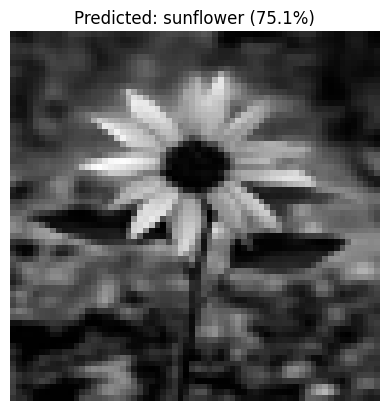

In [71]:
#Show image
img = Image.open(test_image).convert('L').resize((64, 64))

plt.imshow(img, cmap='gray')
plt.title(f"Predicted: {result['predicted_class']} ({result['confidence']:.1%})")
plt.axis('off')
plt.show()

Analysis:
Correct prediction at 75.1% confidence, the function works end to end.

Worth noting: this image sits dead center with a dark disc surrounded by bright petals, right where the importance heatmap showed the model looking. Ideal case.

Also note this was likely a training image, so high confidence is expected and doesn't measure generalization. Your 64.5% test accuracy is the honest number.

#Part 6: Bonus: Comparing with SVM:

In [74]:
#1. Implement SVM classification using SVC from sklearn.svm.
svm = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)

svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)

print("SVM Accuracy:", round(accuracy_score(y_test, y_pred_svm), 4))
print()
print(classification_report(y_test, y_pred_svm))
print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred_svm, labels=svm.classes_))
print("Label order:", svm.classes_)

SVM Accuracy: 0.6129

              precision    recall  f1-score   support

   dalmatian       0.53      0.57      0.55        14
 dollar_bill       0.86      0.60      0.71        10
       pizza       0.86      0.60      0.71        10
 soccer_ball       0.50      0.45      0.48        11
   sunflower       0.57      0.76      0.65        17

    accuracy                           0.61        62
   macro avg       0.66      0.60      0.62        62
weighted avg       0.64      0.61      0.61        62

Confusion matrix:
[[ 8  0  0  2  4]
 [ 2  6  0  1  1]
 [ 1  0  6  1  2]
 [ 2  1  0  5  3]
 [ 2  0  1  1 13]]
Label order: ['dalmatian' 'dollar_bill' 'pizza' 'soccer_ball' 'sunflower']


In [75]:
print("Random Forest:", round(accuracy_score(y_test, y_pred), 4))
print("SVM:          ", round(accuracy_score(y_test, y_pred_svm), 4))

Random Forest: 0.6452
SVM:           0.6129


In [76]:
#2. Follow a similar process as with Random Forest to train and evaluate the SVM model.
#Paramed Grid
param_grid_svm = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 0.001, 0.01, 0.1],
    'kernel': ['rbf', 'linear']
}

In [77]:
#create the classifier
svm = SVC(random_state=42)

In [78]:
#Grid Searchfrom sklearn.model_selection import GridSearchCV
grid_search_svm = GridSearchCV(estimator=svm, param_grid=param_grid_svm, cv=3, scoring='accuracy', n_jobs=-1, verbose=2)

grid_search_svm.fit(X_train, y_train)

Fitting 3 folds for each of 32 candidates, totalling 96 fits


GridSearchCV(cv=3, estimator=SVC(random_state=42), n_jobs=-1,
             param_grid={'C': [0.1, 1, 10, 100],
                         'gamma': ['scale', 0.001, 0.01, 0.1],
                         'kernel': ['rbf', 'linear']},
             scoring='accuracy', verbose=2)

In [80]:
#Best parameter and model
print("Best parameters:", grid_search_svm.best_params_)
print("Best CV accuracy:", round(grid_search_svm.best_score_, 4))

best_svm = grid_search_svm.best_estimator_

Best parameters: {'C': 10, 'gamma': 0.001, 'kernel': 'rbf'}
Best CV accuracy: 0.6519


In [81]:
#Predic on the test set
y_pred_svm = best_svm.predict(X_test)

In [82]:
#Evaluate
print("Accuracy :", round(accuracy_score(y_test, y_pred_svm), 4))
print("Precision:", round(precision_score(y_test, y_pred_svm, average='weighted'), 4))
print("Recall   :", round(recall_score(y_test, y_pred_svm, average='weighted'), 4))
print("F1-score :", round(f1_score(y_test, y_pred_svm, average='weighted'), 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_svm, labels=best_svm.classes_))
print("Label order:", best_svm.classes_)

Accuracy : 0.5806
Precision: 0.6033
Recall   : 0.5806
F1-score : 0.578

Classification Report:
              precision    recall  f1-score   support

   dalmatian       0.53      0.57      0.55        14
 dollar_bill       0.67      0.60      0.63        10
       pizza       0.80      0.40      0.53        10
 soccer_ball       0.55      0.55      0.55        11
   sunflower       0.55      0.71      0.62        17

    accuracy                           0.58        62
   macro avg       0.62      0.56      0.58        62
weighted avg       0.60      0.58      0.58        62

Confusion Matrix:
[[ 8  0  0  2  4]
 [ 2  6  0  1  1]
 [ 1  1  4  1  3]
 [ 2  1  0  6  2]
 [ 2  1  1  1 12]]
Label order: ['dalmatian' 'dollar_bill' 'pizza' 'soccer_ball' 'sunflower']


Analysis:
All three runs land between 58% and 68%, and the same classes fail the same way each time. That consistency points at the features, not the model. Grayscale center pixels can't separate these classes, so switching algorithms just shuffles which errors you get.

In [86]:
#Compare the results of Random Forest and SVM models.
#Finally, compare the two models side by side
print("Random Forest:", round(accuracy_score(y_test, y_pred), 4))
print("SVM:          ", round(accuracy_score(y_test, y_pred_svm), 4))

Random Forest: 0.6452
SVM:           0.5806
